# Phase 8: Final Paper Visualizations and LaTeX Tables

This notebook:
1. Executes `scripts/generate_paper_visualizations.py` to regenerate all tradeoff plots, consistency charts, heatmaps, ROC curves, and LaTeX table source files in both PNG and PDF.
2. Displays the generated utility-privacy tradeoff plots in-line.
3. Displays the SHAP consistency bar charts in-line.
4. Displays the SHAP feature-rank heatmaps in-line.
5. Displays the downstream classification model ROC curves in-line.
6. Displays the Membership Inference Attack (MIA) ROC curves in-line.
7. Prints the generated LaTeX table markup for the final paper manuscript.

In [1]:
import os
import sys

# Smart working directory adjustment: change to repository root if started inside subdirectories
current_dir = os.getcwd()
if os.path.basename(current_dir) == '07_paper_figures':
    os.chdir('../../')
elif os.path.basename(current_dir) == 'notebooks':
    os.chdir('../')
print(f'Current working directory: {os.getcwd()}')

# Run the script to generate visualizations
import subprocess
result = subprocess.run([sys.executable, 'scripts/generate_paper_visualizations.py'], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr, file=sys.stderr)

Current working directory: C:\Users\Isha\Desktop\shap-synthetic-credit-risk


Shap Synthetic Credit Risk: Generating Final Paper Visualizations

Generating Utility-Privacy tradeoff scatter plots...
Utility-Privacy tradeoff plot saved to figures/paper/german_credit_utility_privacy_tradeoff.png (and PDF)
Utility-Privacy tradeoff plot saved to figures/paper/gmsc_utility_privacy_tradeoff.png (and PDF)

Generating SHAP consistency comparison plots...
SHAP consistency comparison plot saved to figures/paper/german_credit_shap_consistency.png (and PDF)
SHAP consistency comparison plot saved to figures/paper/gmsc_shap_consistency.png (and PDF)

Generating SHAP feature-rank heatmaps...
SHAP feature-rank heatmap saved to figures/paper/german_credit_shap_heatmap.png (and PDF)
SHAP feature-rank heatmap saved to figures/paper/gmsc_shap_heatmap.png (and PDF)

Generating Downstream Model ROC curves...
Preprocessing German Credit dataset...
German Credit dataset preprocessing completed successfully!
Model ROC curves saved to figures/paper/german_credit_roc_curve.png (and PDF)
Pr

## 1. Display Generated Tradeoff Plots

We load and display the scatter plots that map downstream classification utility (ROC-AUC) on the Y-axis against tabular privacy (DCR distance) on the X-axis.

--- German Credit Utility-Privacy Tradeoff ---


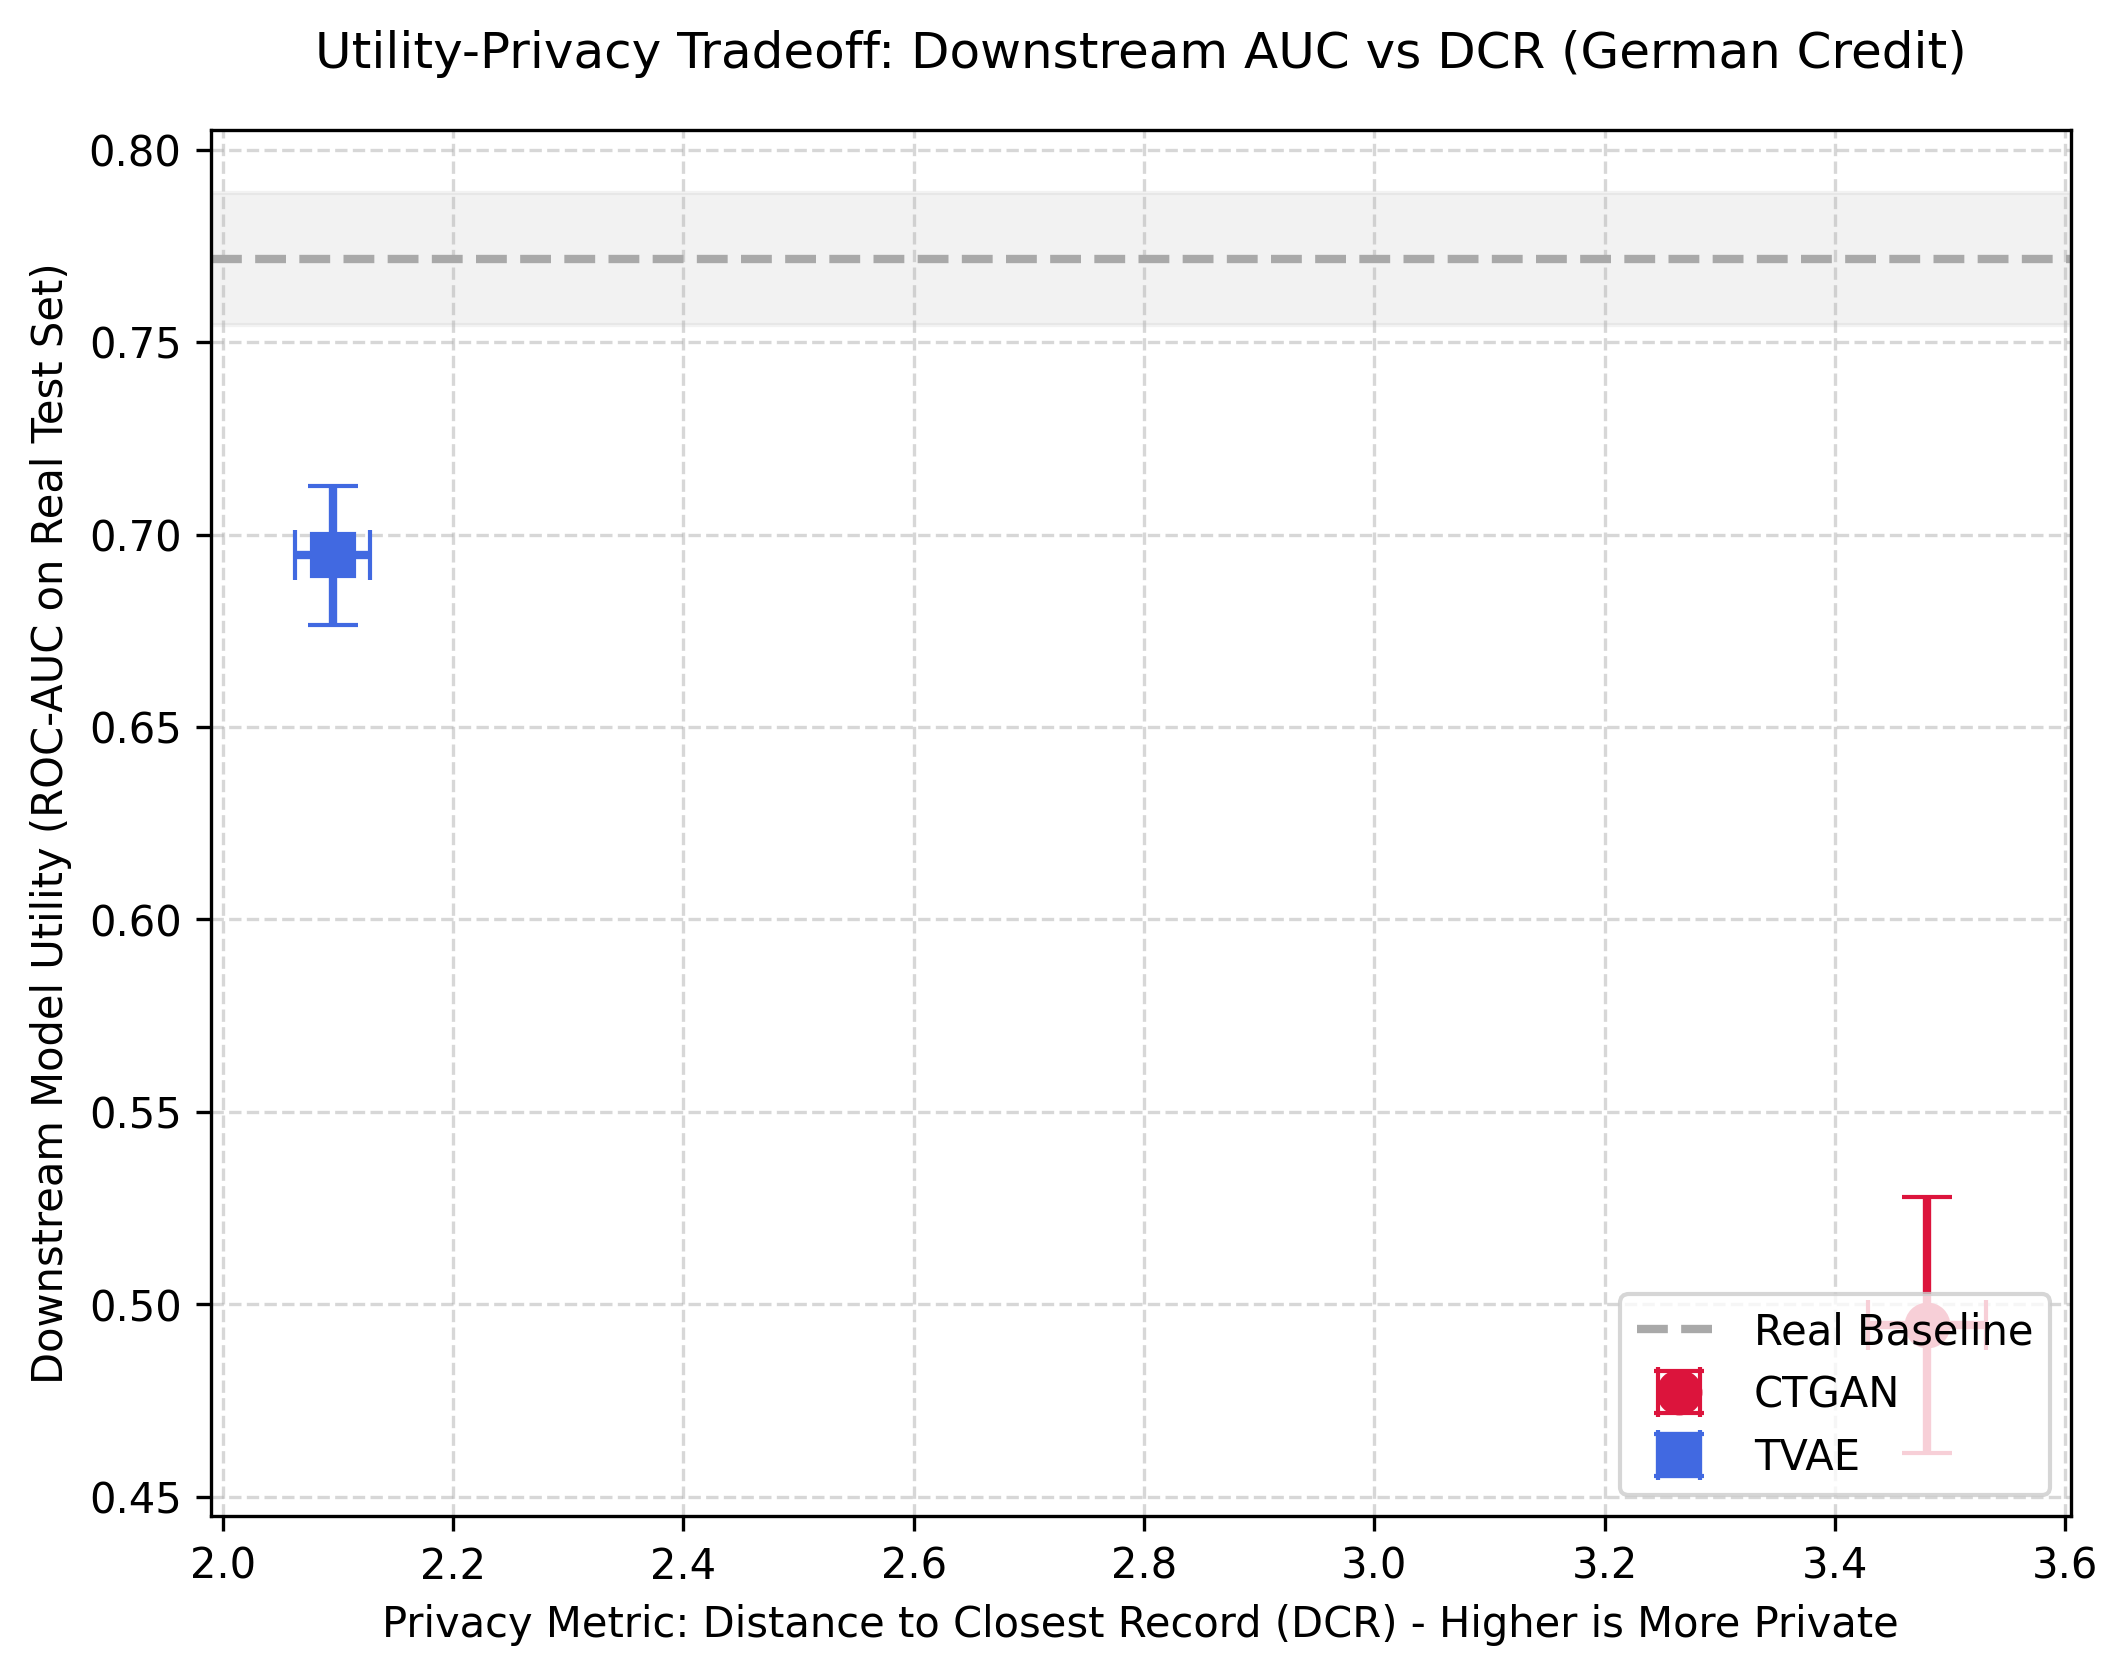


--- GMSC Utility-Privacy Tradeoff ---


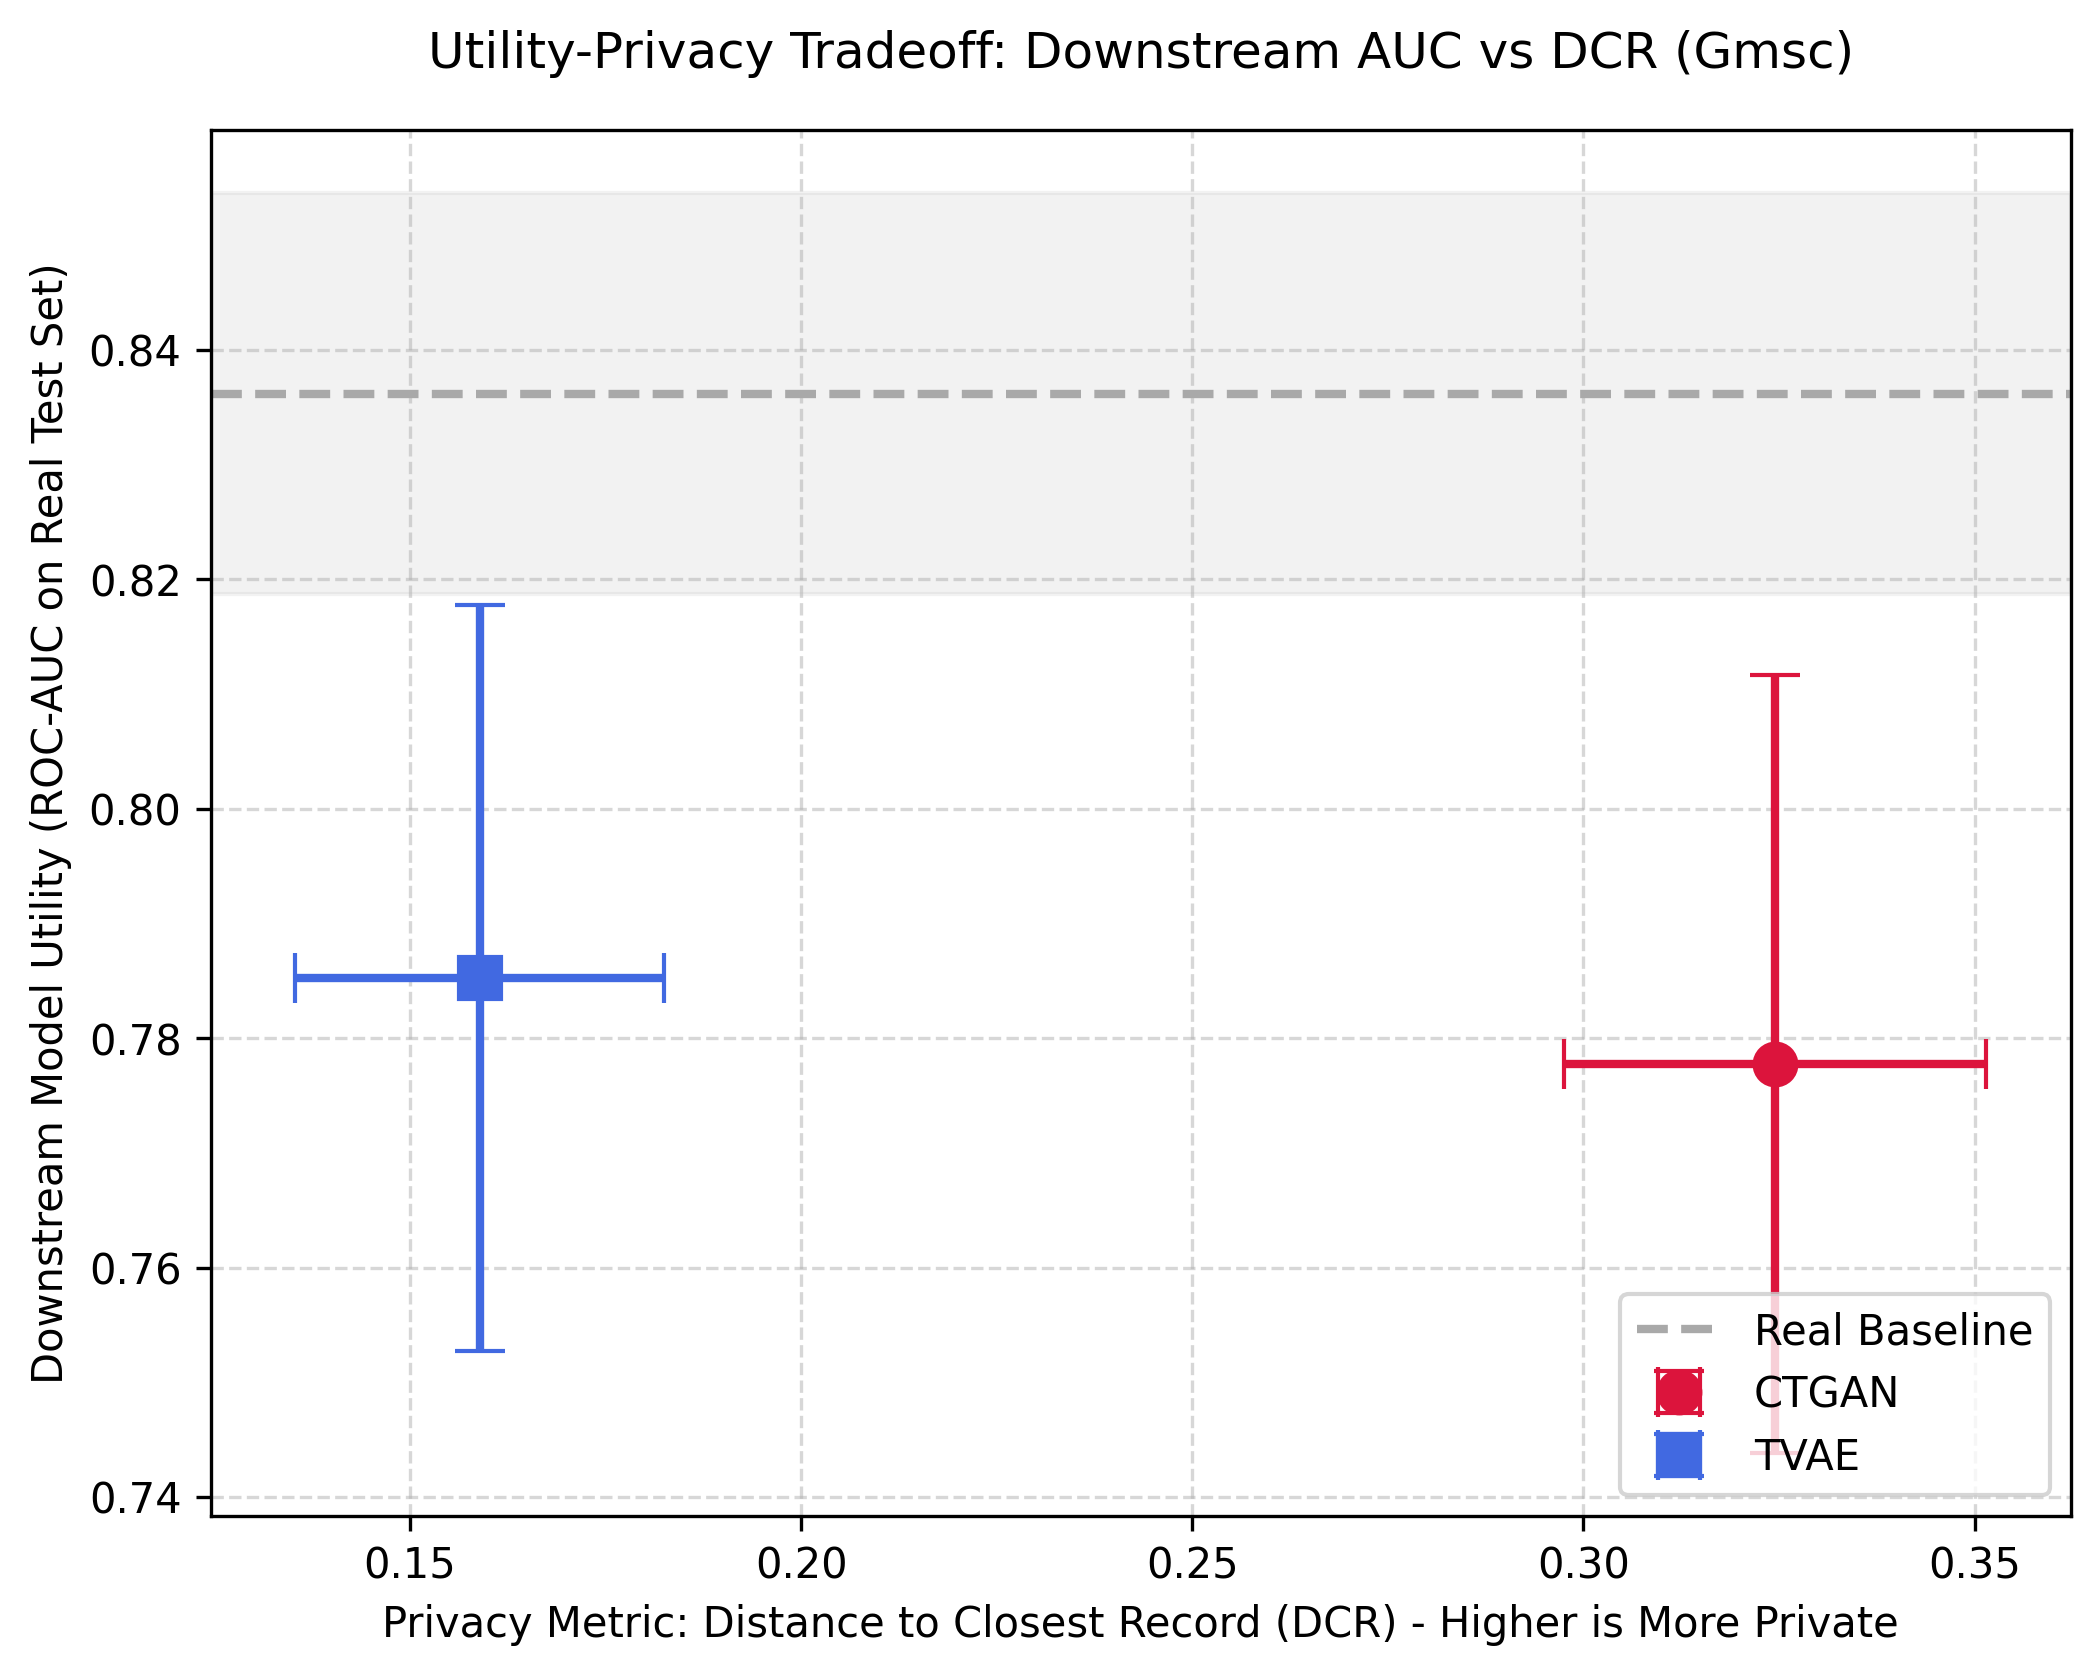

In [2]:
from IPython.display import Image, display

print('--- German Credit Utility-Privacy Tradeoff ---')
display(Image(filename='figures/paper/german_credit_utility_privacy_tradeoff.png'))

print('\n--- GMSC Utility-Privacy Tradeoff ---')
display(Image(filename='figures/paper/gmsc_utility_privacy_tradeoff.png'))

## 2. Display SHAP Consistency Plots

We display the bar plots comparing the consistency of synthetic feature importances vs. real baseline feature importances (Spearman rank correlation $\rho$).

--- German Credit SHAP Consistency ---


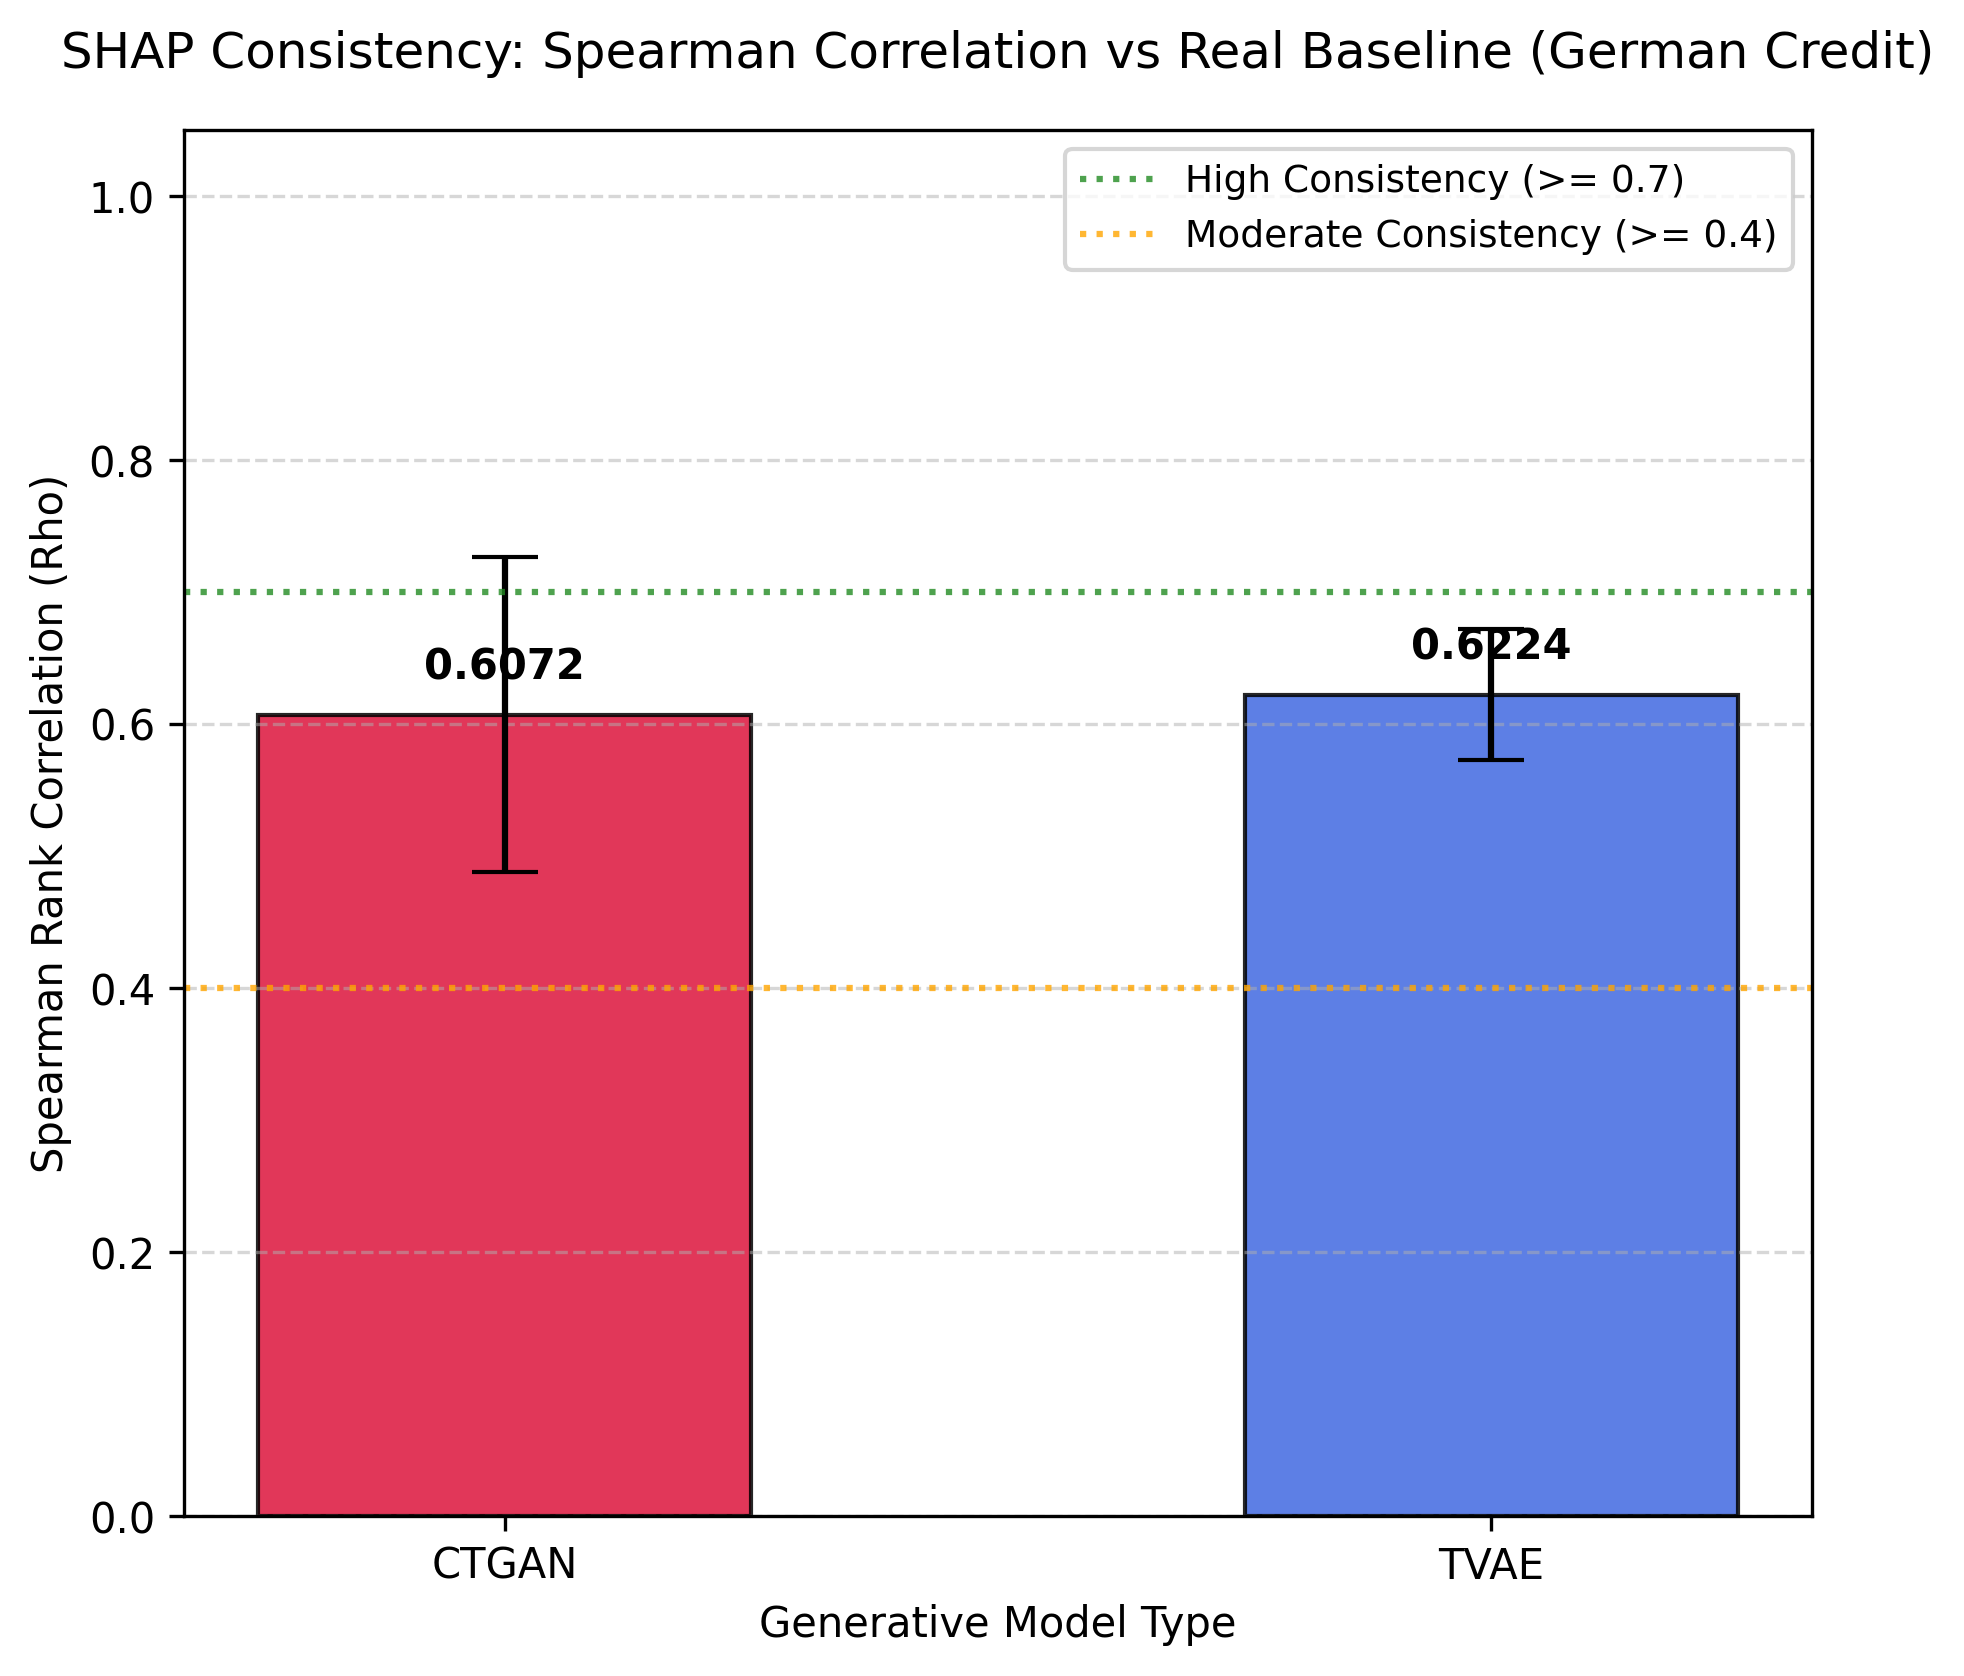


--- GMSC SHAP Consistency ---


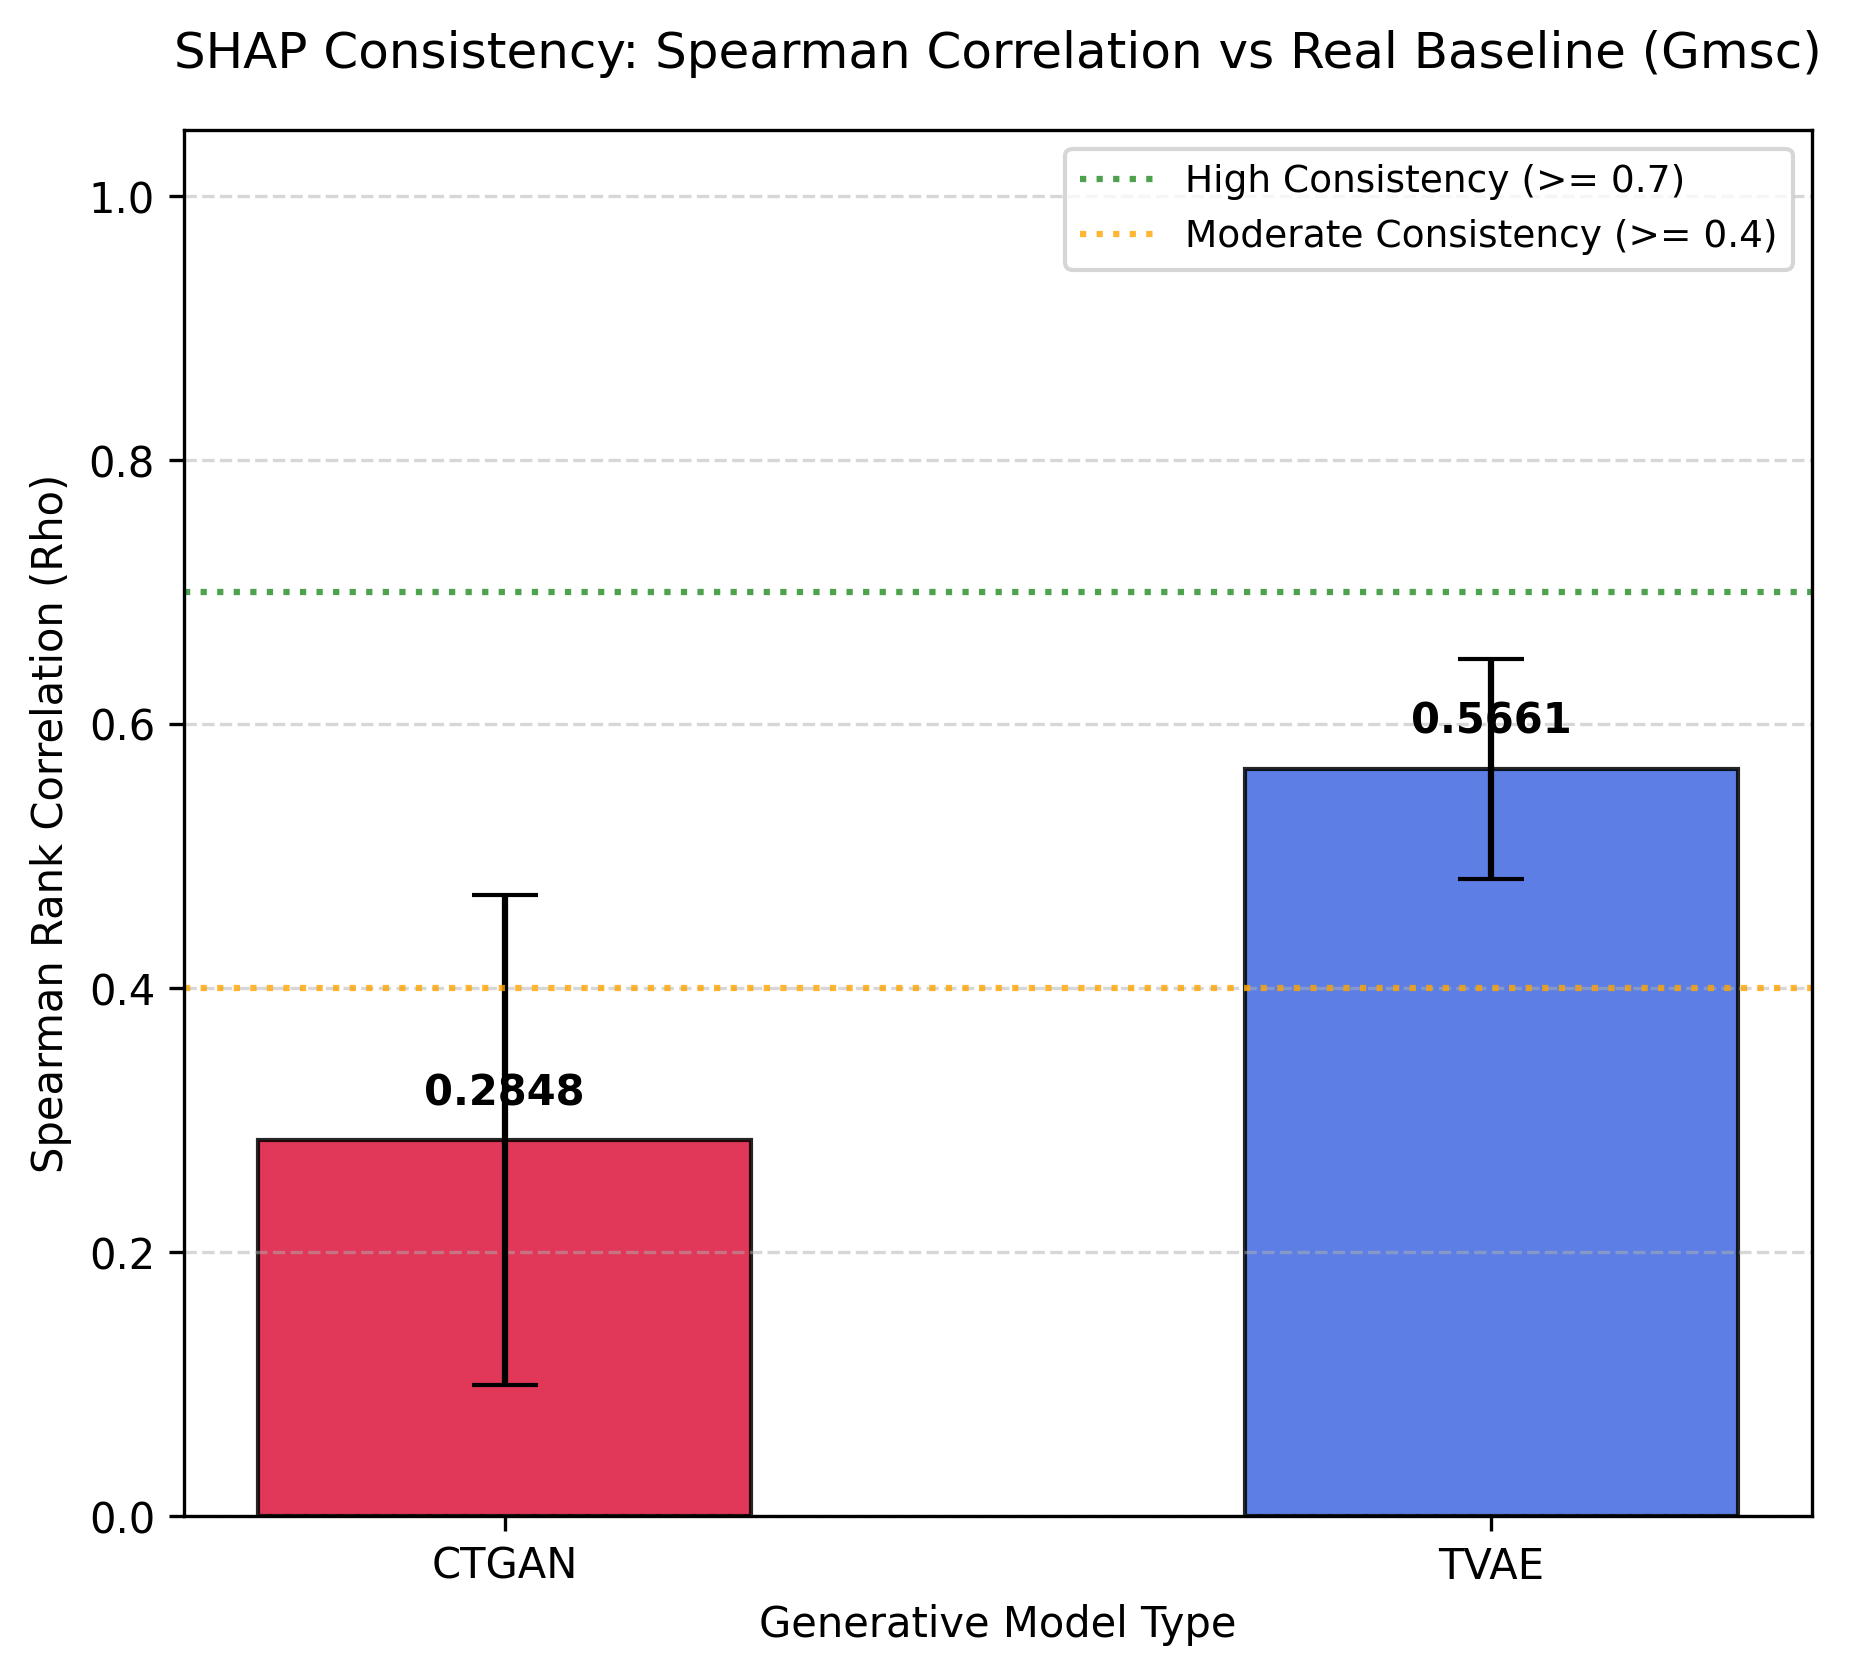

In [3]:
print('--- German Credit SHAP Consistency ---')
display(Image(filename='figures/paper/german_credit_shap_consistency.png'))

print('\n--- GMSC SHAP Consistency ---')
display(Image(filename='figures/paper/gmsc_shap_consistency.png'))

## 3. Display SHAP Feature-Rank Heatmaps

We display the heatmaps that compare the mean SHAP rank positions of features across Real Baseline, CTGAN, and TVAE model predictions.

--- German Credit SHAP Feature-Rank Heatmap ---


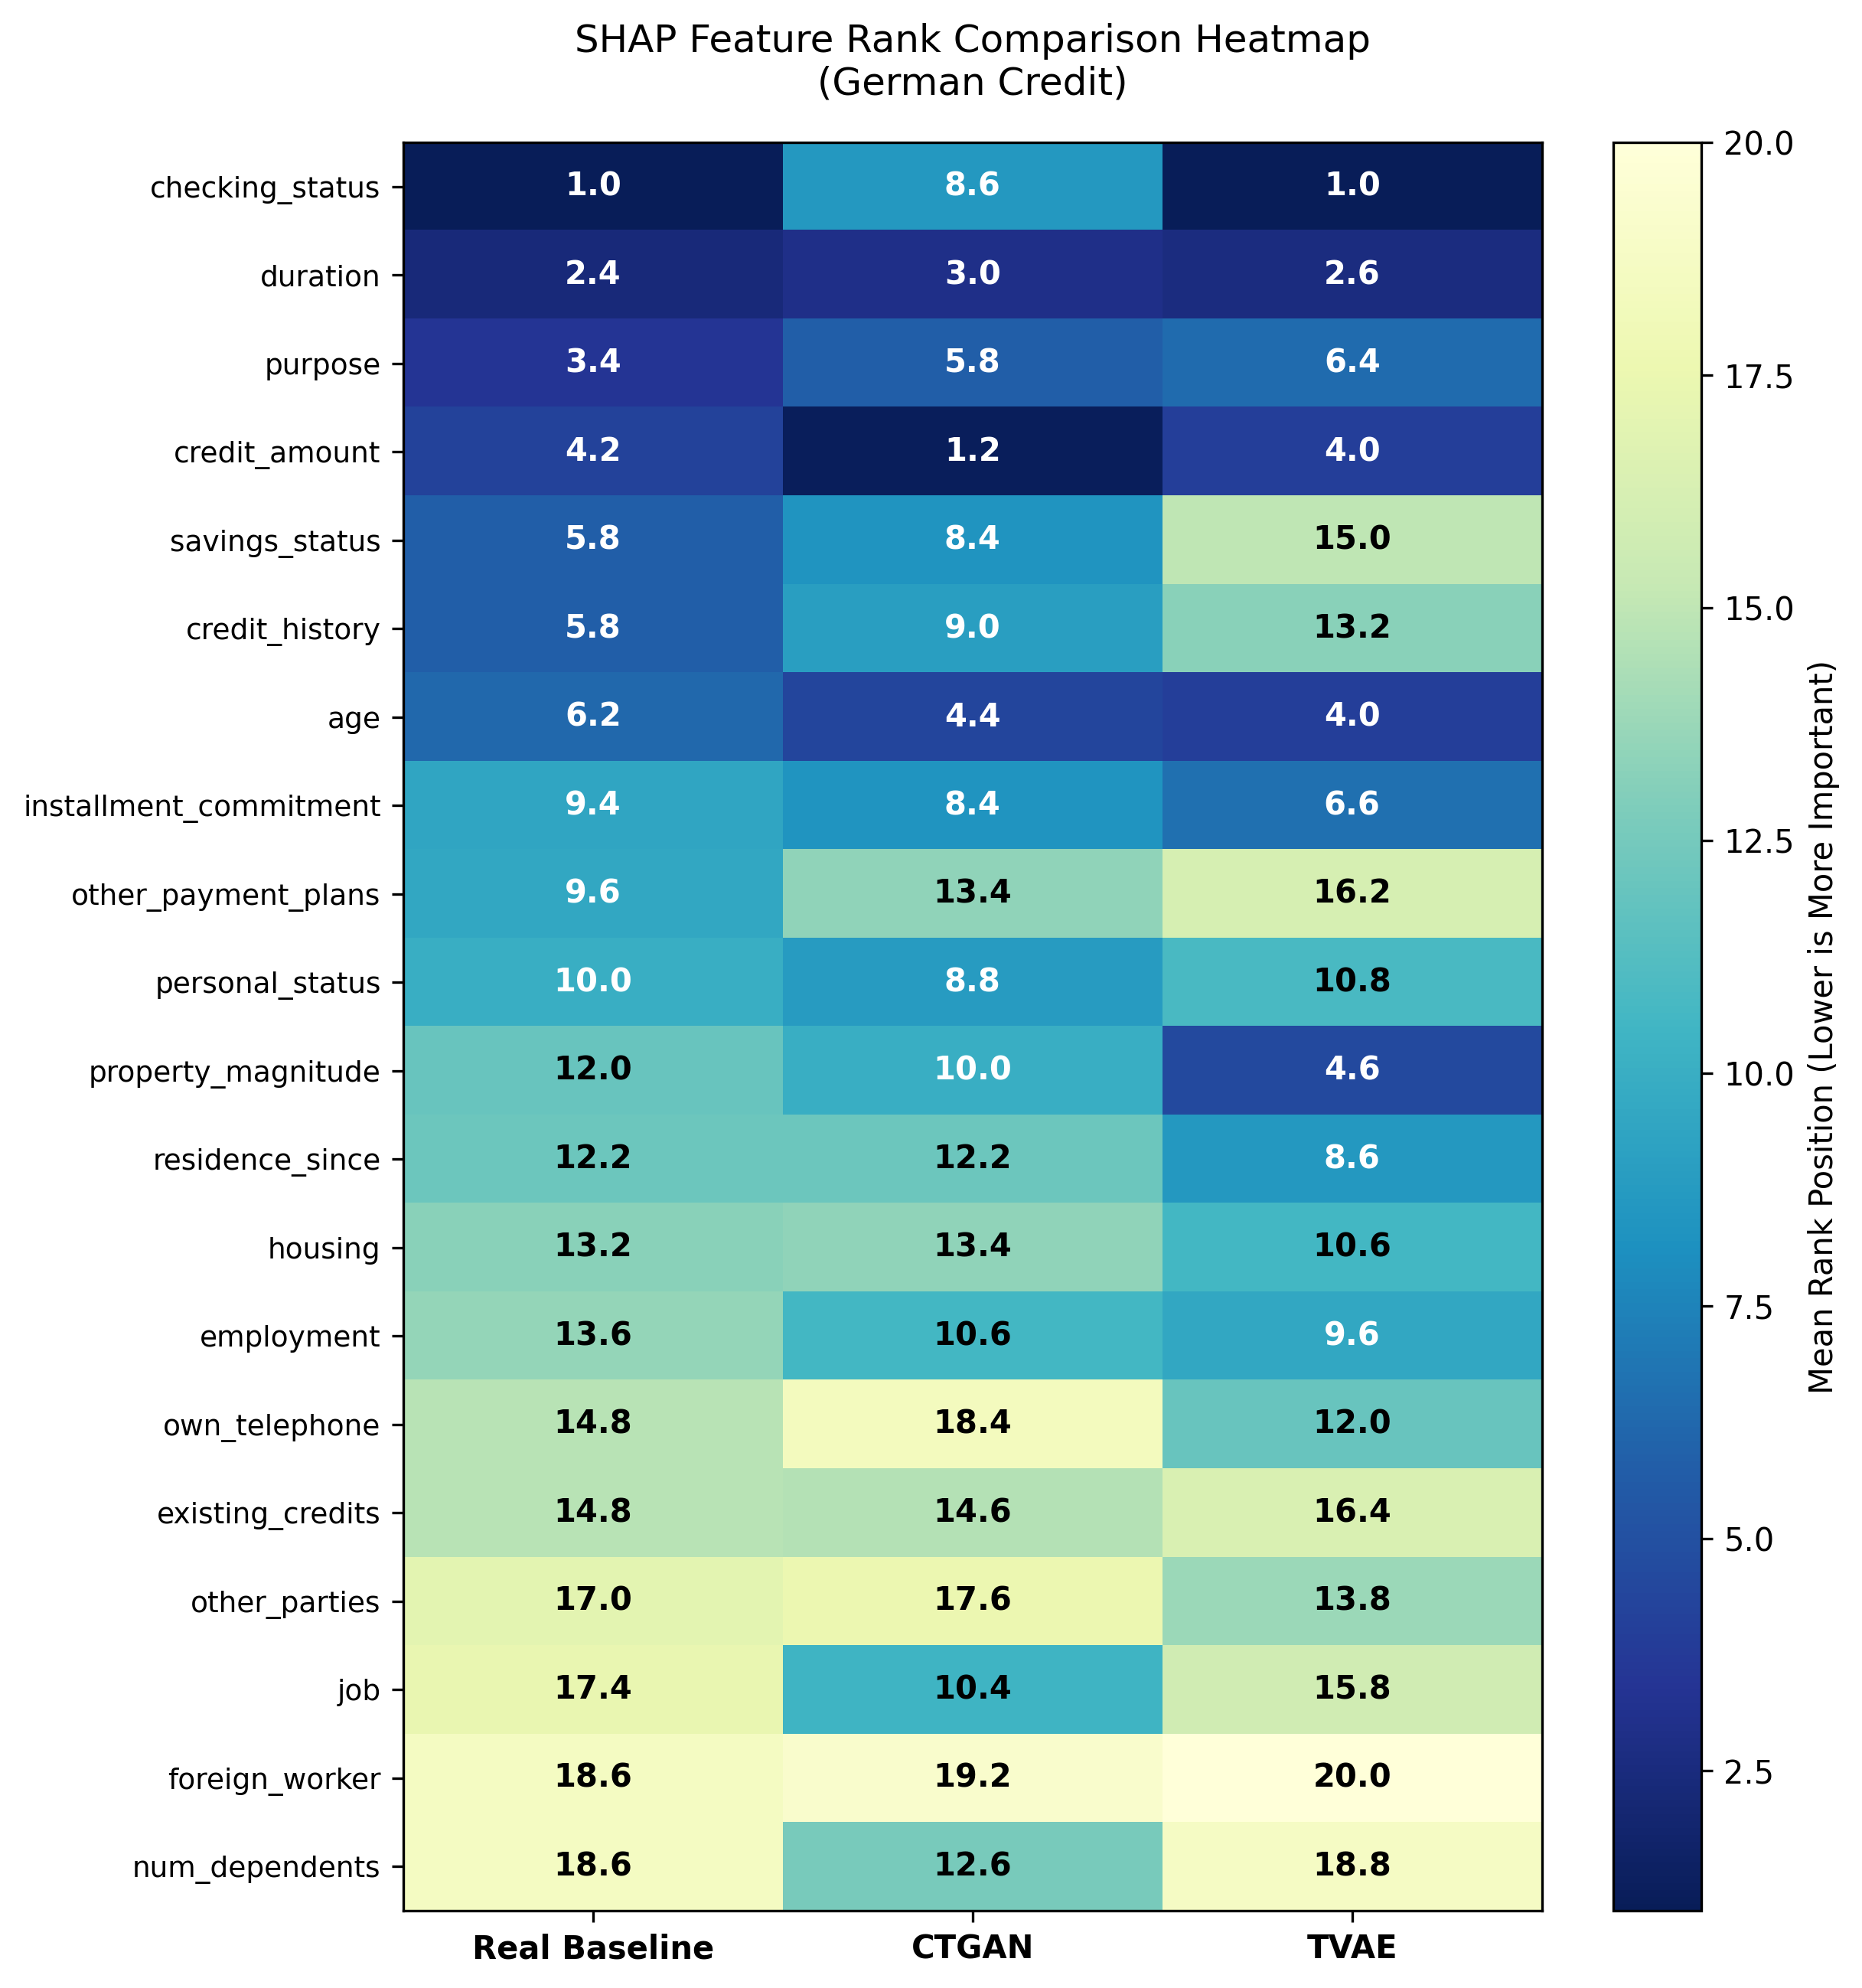


--- GMSC SHAP Feature-Rank Heatmap ---


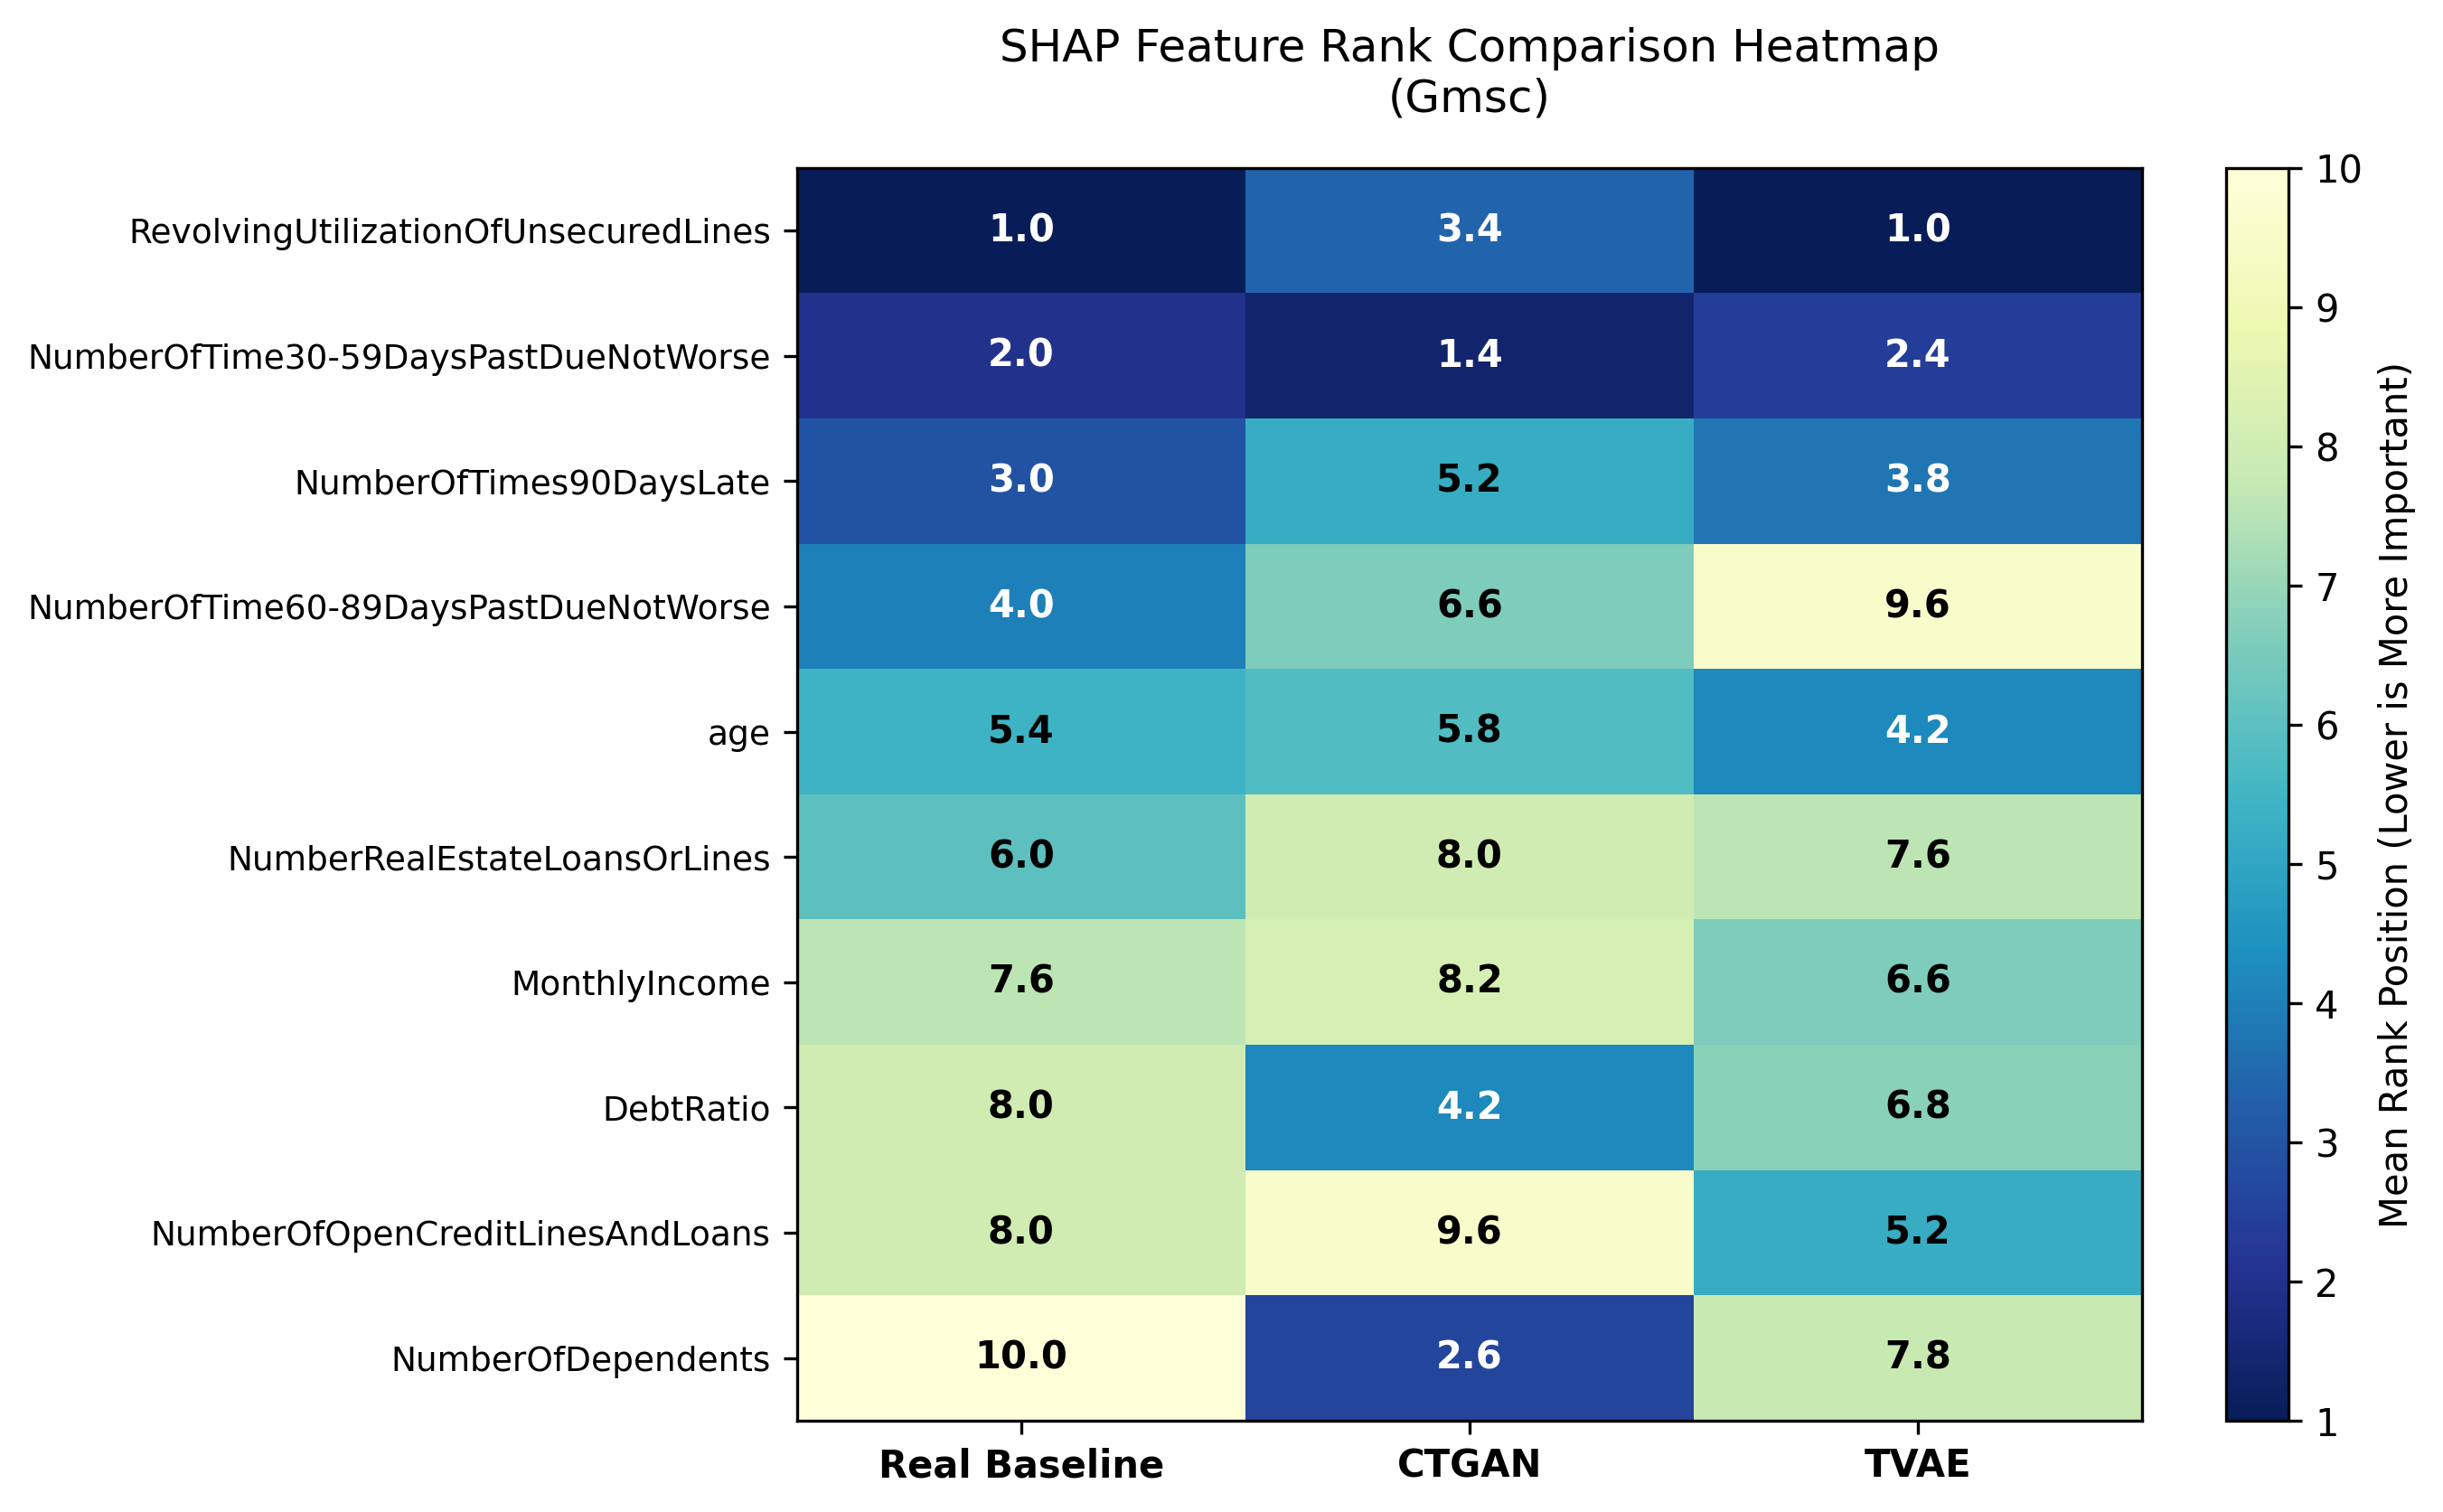

In [4]:
print('--- German Credit SHAP Feature-Rank Heatmap ---')
display(Image(filename='figures/paper/german_credit_shap_heatmap.png'))

print('\n--- GMSC SHAP Feature-Rank Heatmap ---')
display(Image(filename='figures/paper/gmsc_shap_heatmap.png'))

## 4. Display Downstream Model ROC Curves

We display the ROC curves of XGBoost models trained on Real, CTGAN, and TVAE datasets evaluated on the Real Test split for Seed 42.

--- German Credit Model ROC Curves ---


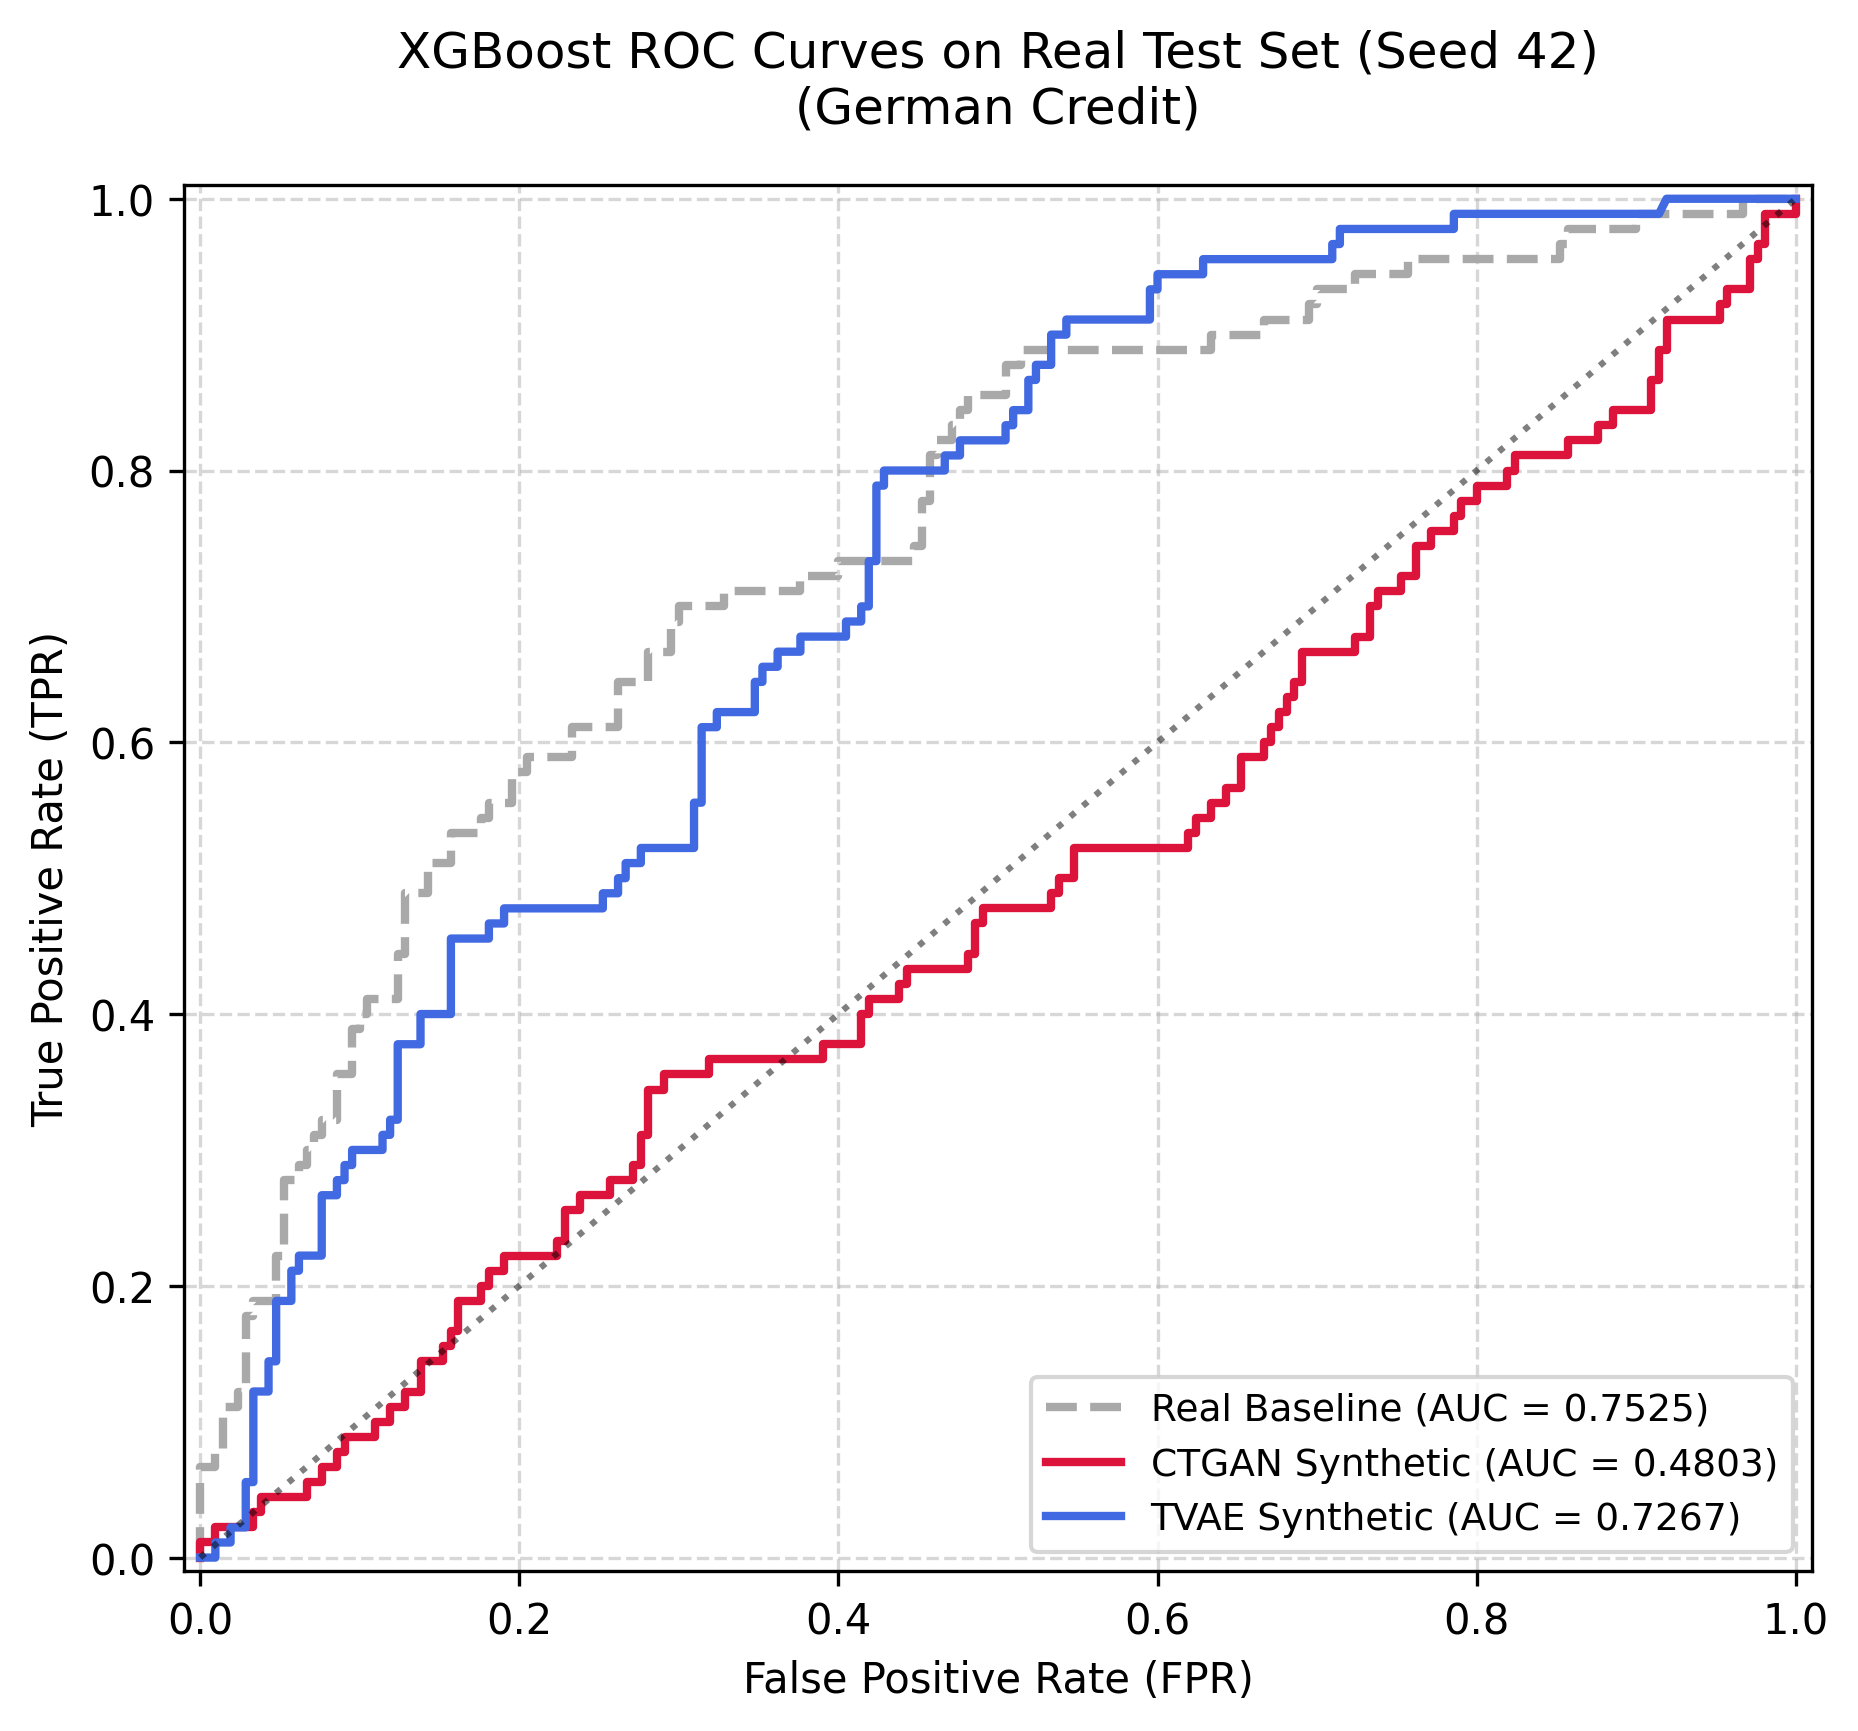


--- GMSC Model ROC Curves ---


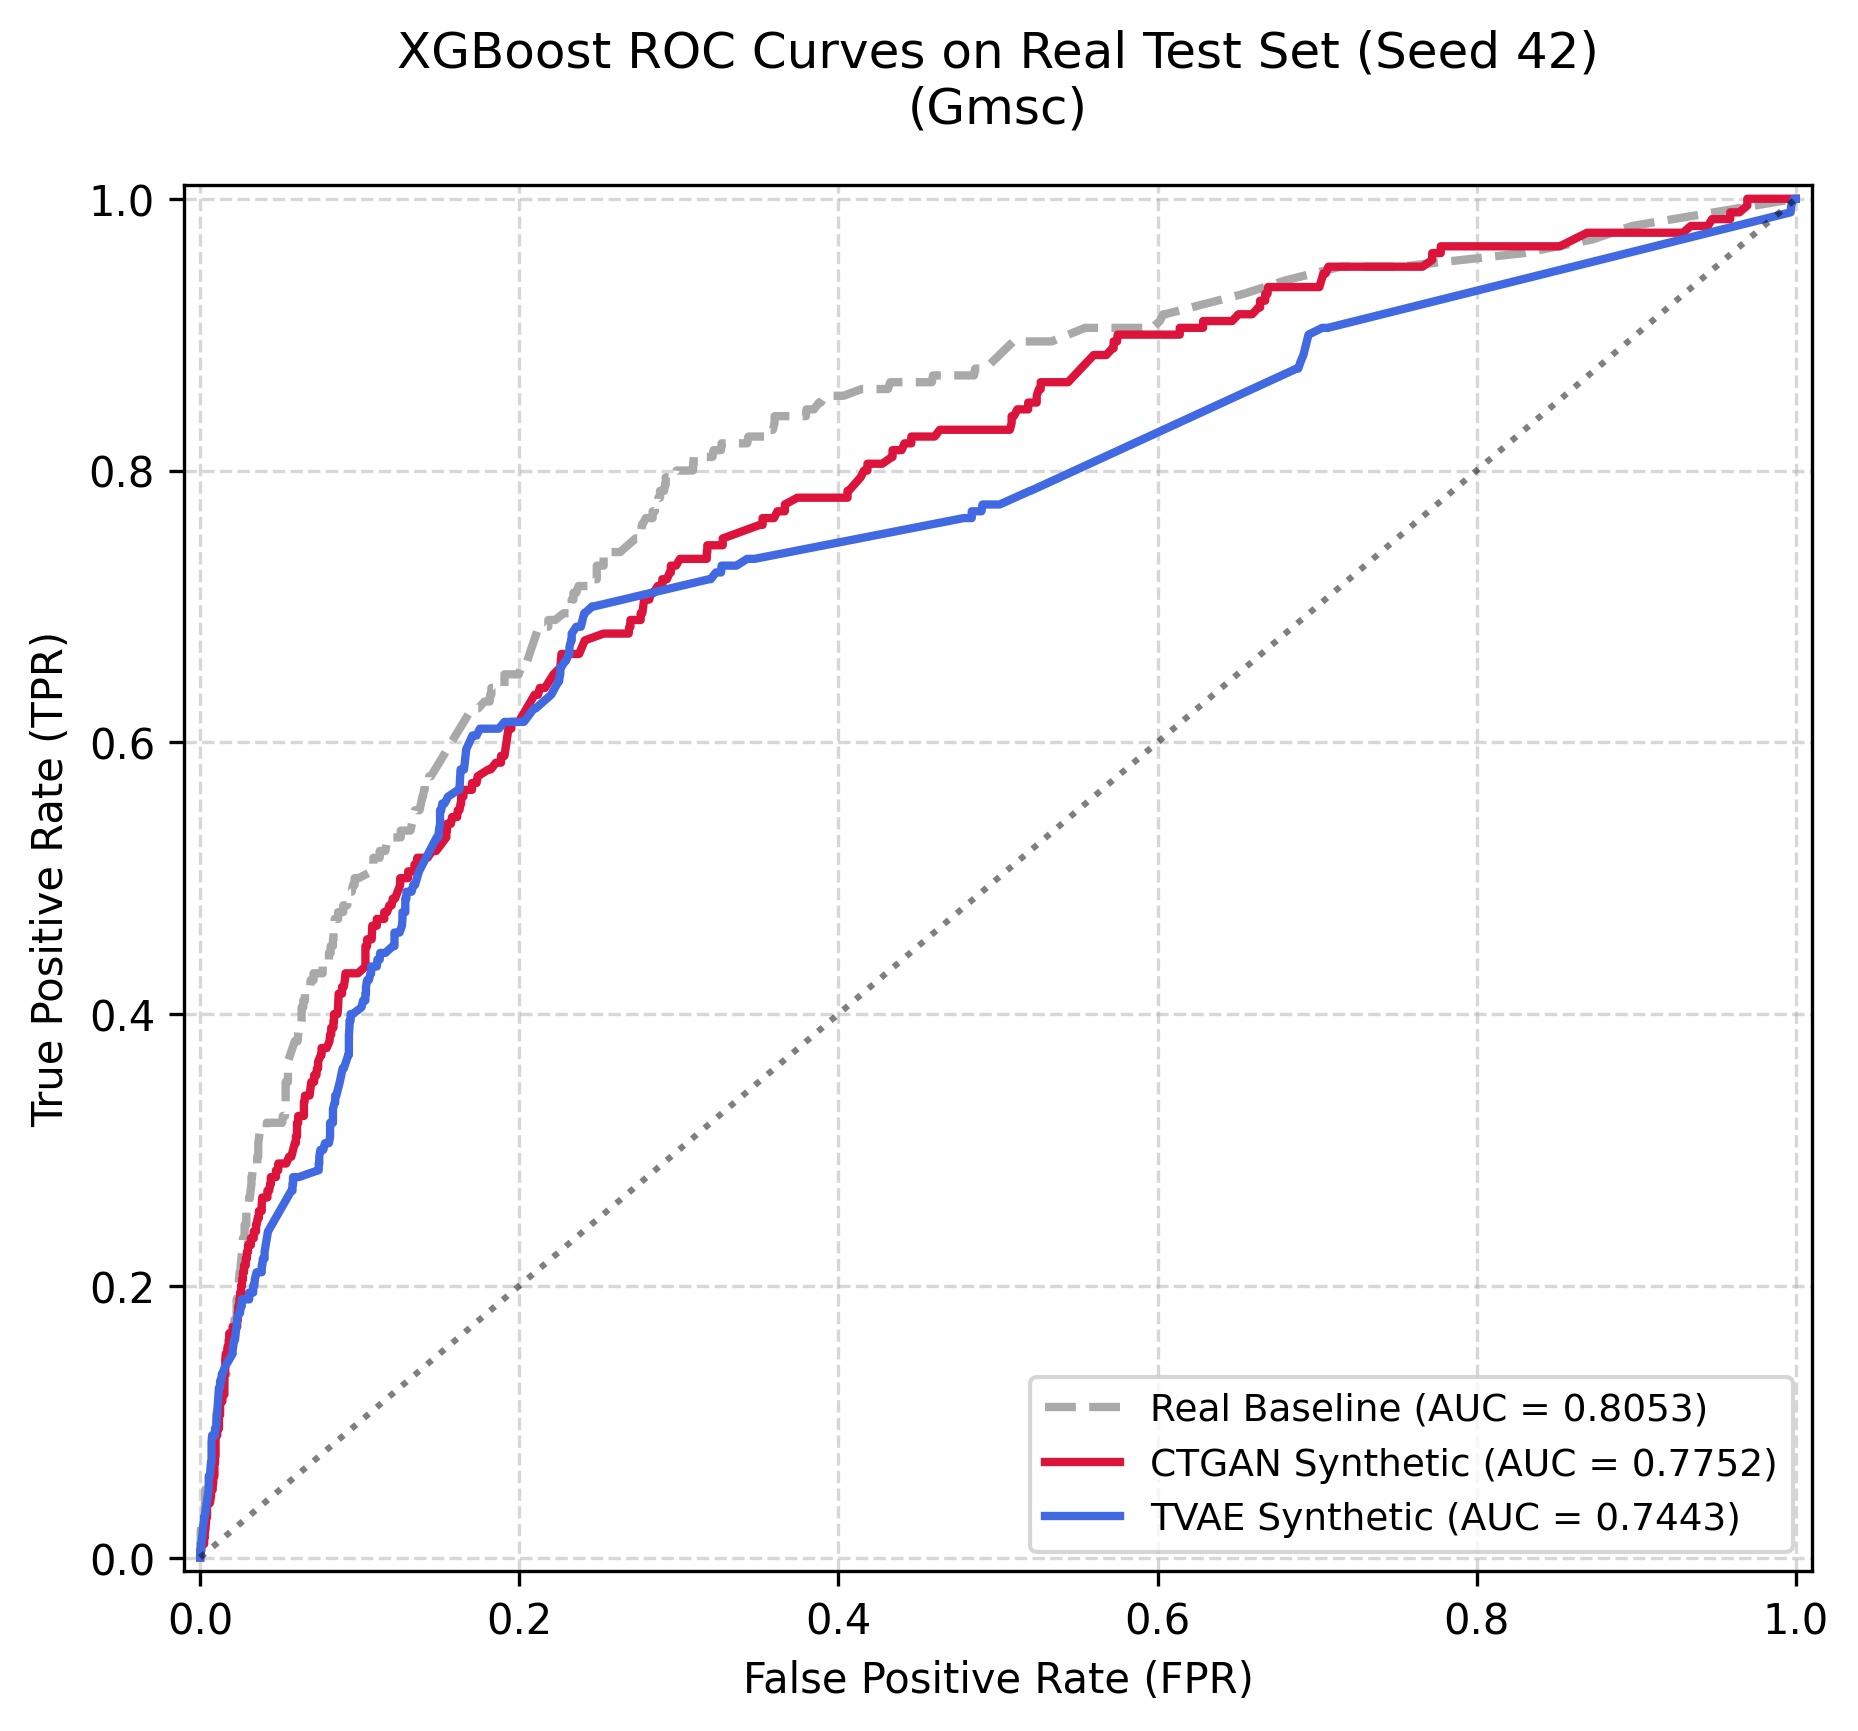

In [5]:
print('--- German Credit Model ROC Curves ---')
display(Image(filename='figures/paper/german_credit_roc_curve.png'))

print('\n--- GMSC Model ROC Curves ---')
display(Image(filename='figures/paper/gmsc_roc_curve.png'))

## 5. Display Membership Inference Attack (MIA) ROC Curves

We display the ROC curves of distance-based Membership Inference Attacks (MIA) evaluating the memorization risk of CTGAN and TVAE (Seed 42).

--- German Credit MIA ROC Curves ---


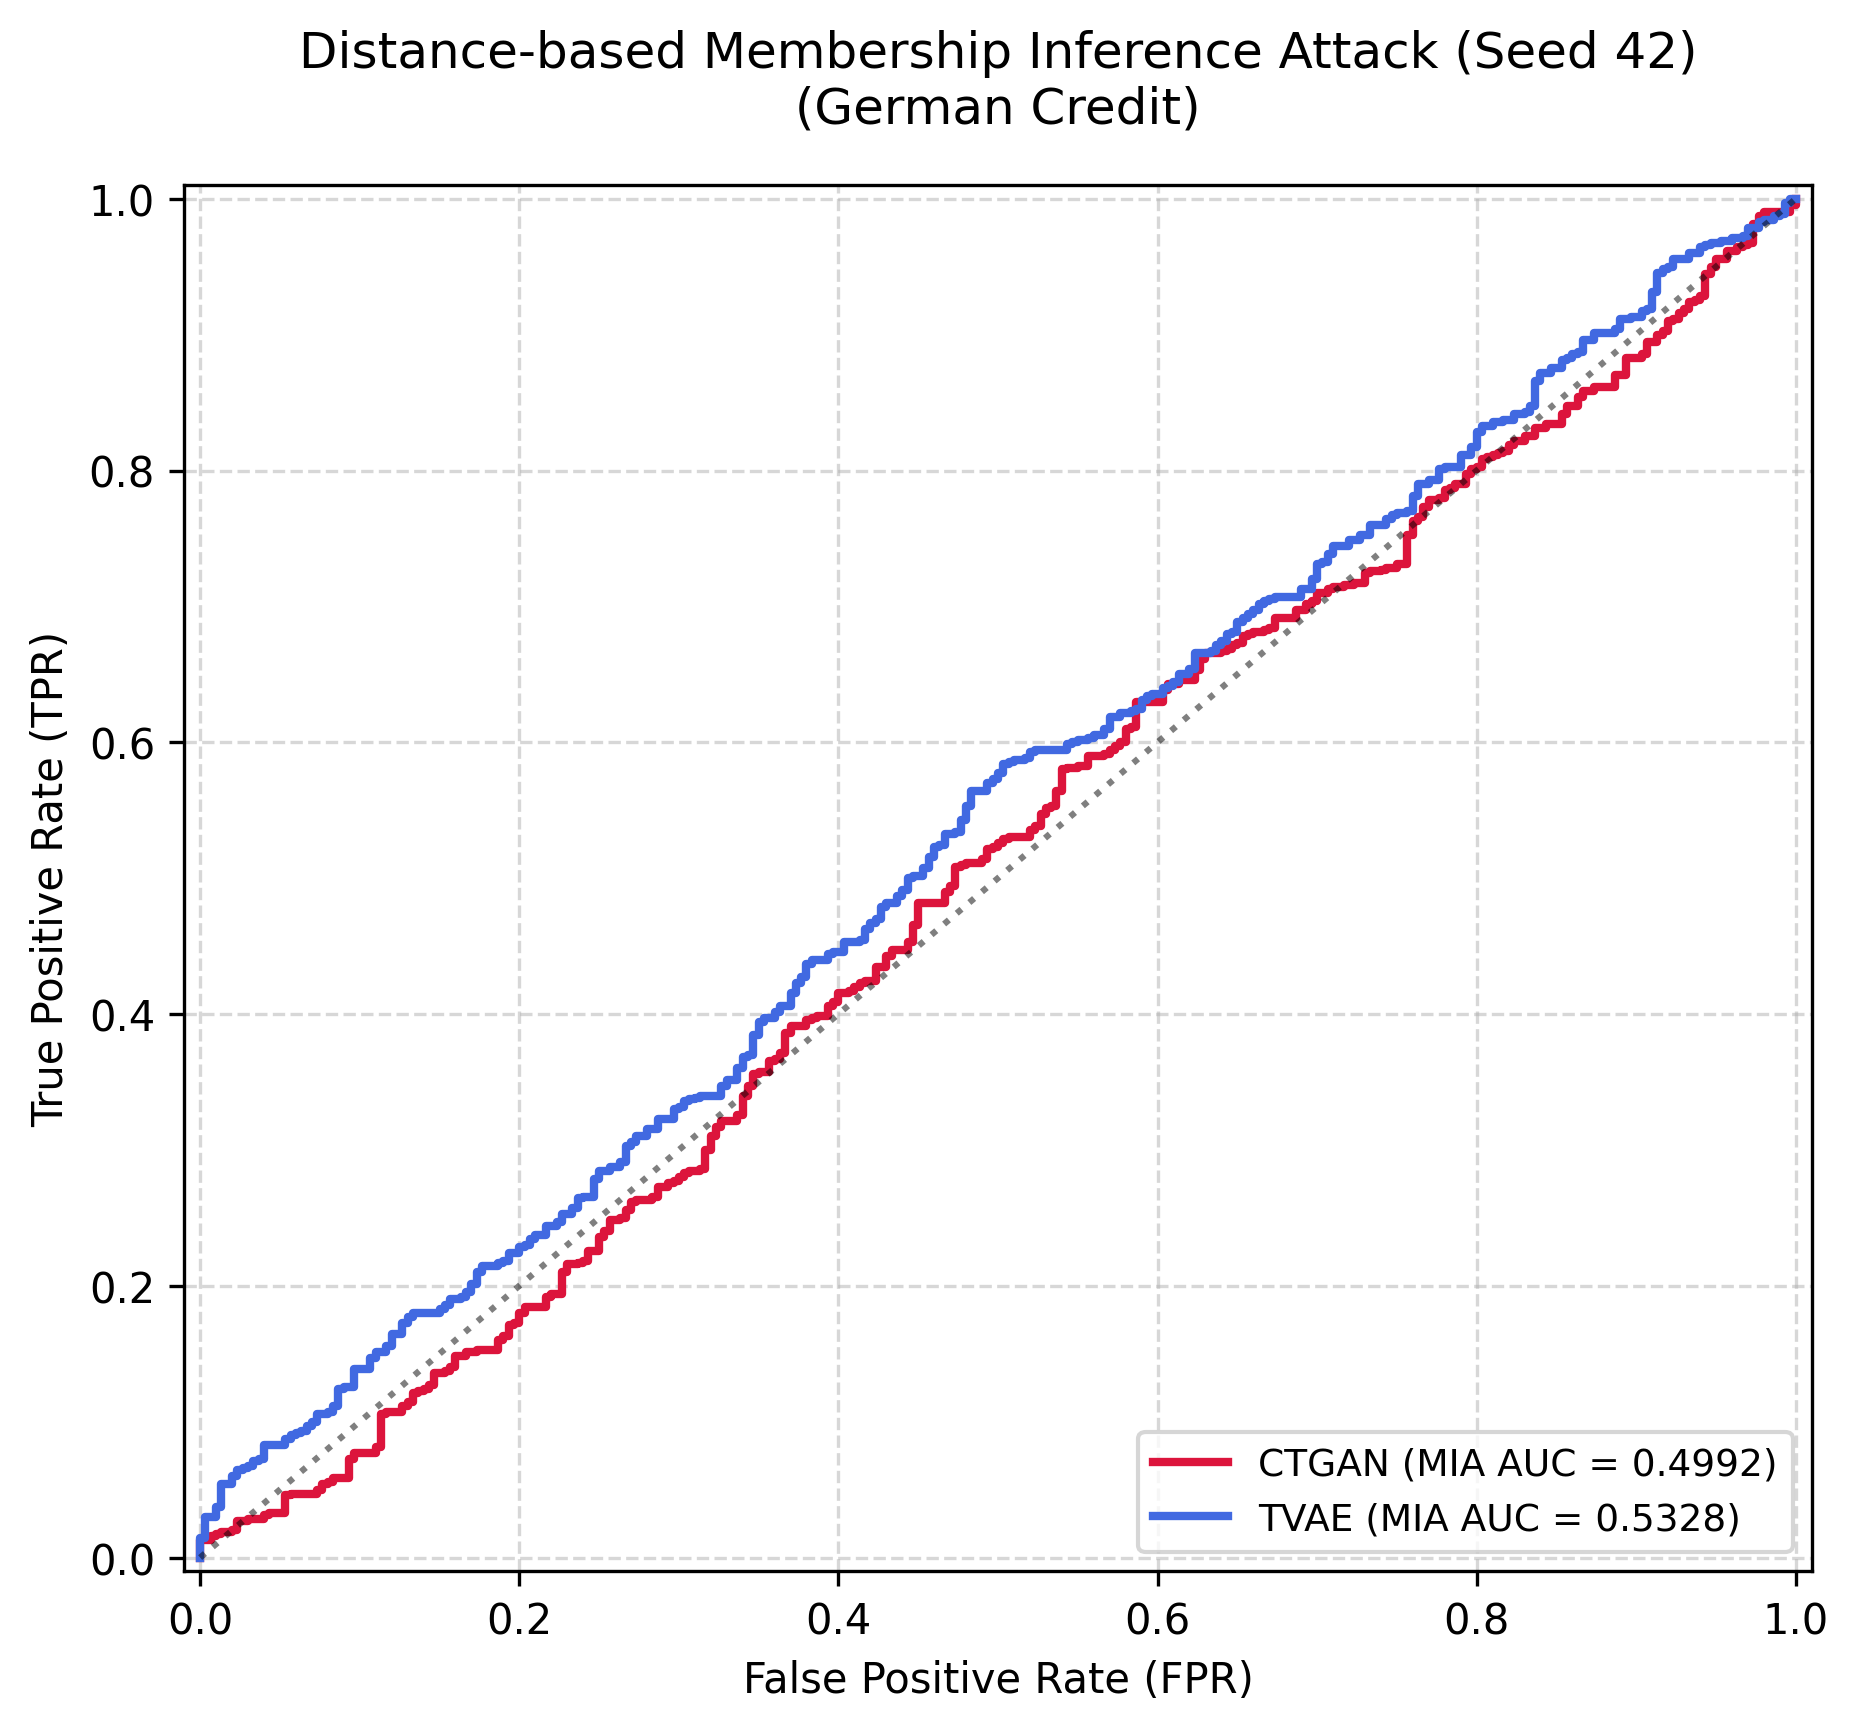


--- GMSC MIA ROC Curves ---


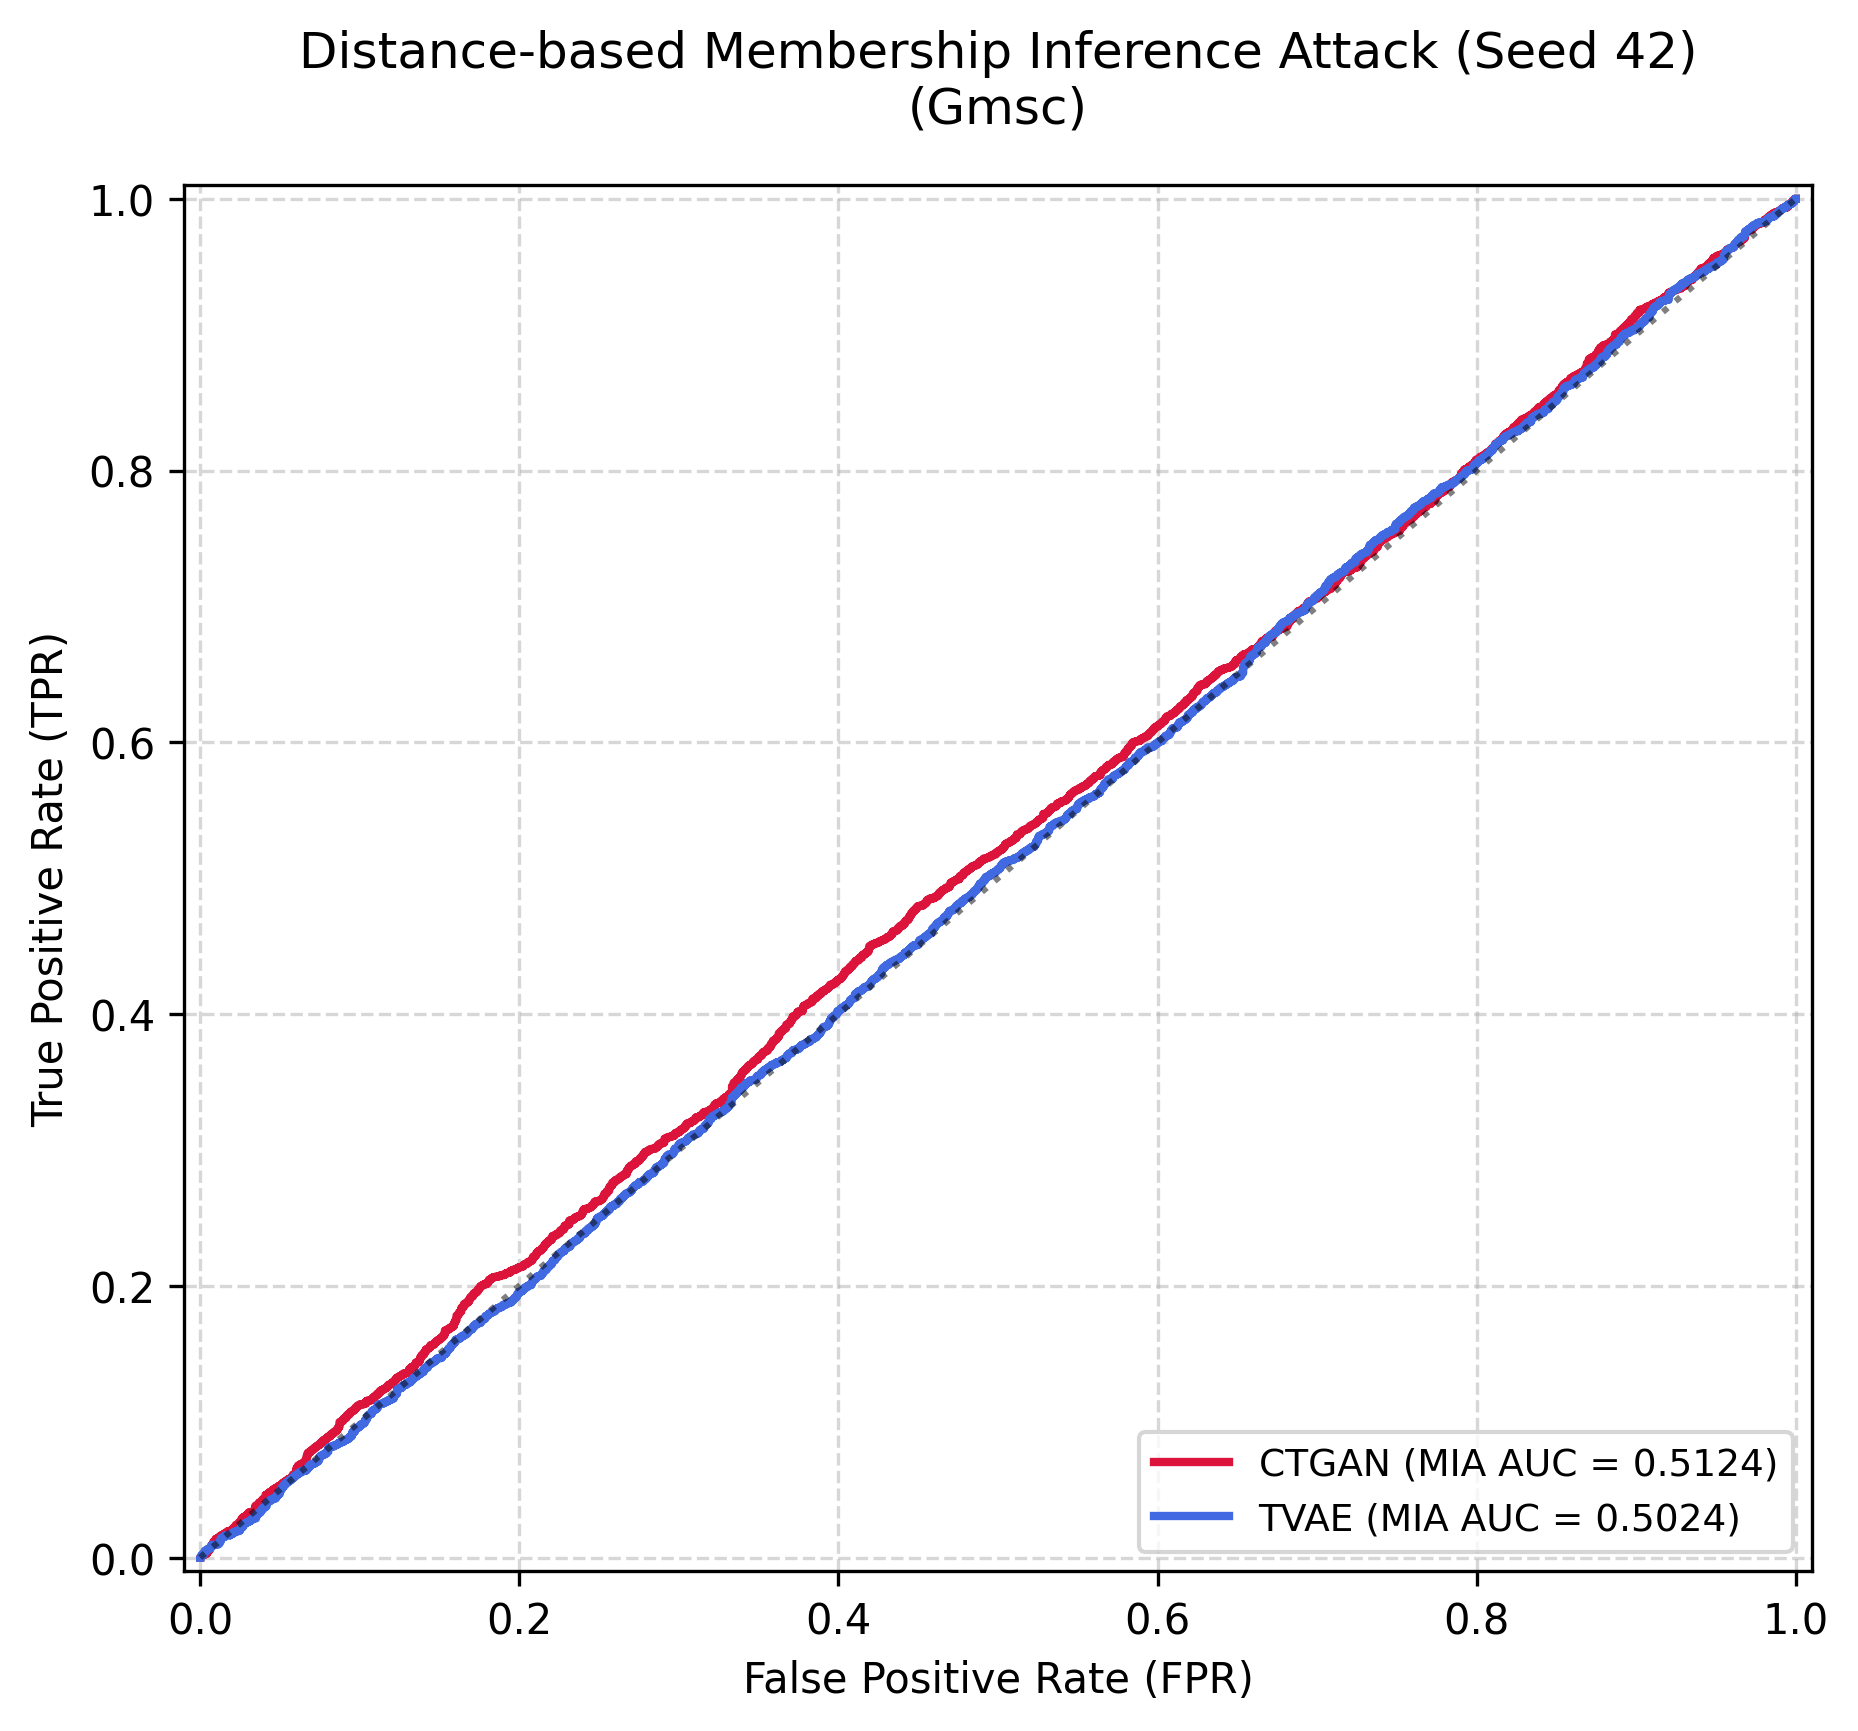

In [6]:
print('--- German Credit MIA ROC Curves ---')
display(Image(filename='figures/paper/german_credit_mia_roc_curve.png'))

print('\n--- GMSC MIA ROC Curves ---')
display(Image(filename='figures/paper/gmsc_mia_roc_curve.png'))

## 6. Print LaTeX Table Markup

Below is the exact LaTeX table markup for copy-pasting directly into the LaTeX document for the research paper.

In [7]:
def print_file_contents(filepath):
    print(f'=== {os.path.basename(filepath)} ===')
    with open(filepath, 'r') as f:
        print(f.read())
    print('\n')

print_file_contents('results/summaries/dataset_statistics_table.tex')
print_file_contents('results/summaries/utility_comparison_table.tex')
print_file_contents('results/summaries/privacy_consistency_comparison_table.tex')

=== dataset_statistics_table.tex ===


\begin{table}[htbp]
\centering
\caption{Key Dataset Characteristics and Evaluation Settings}
\label{tab:dataset_stats}
\begin{tabular}{lccccc}
\hline
\textbf{Dataset} & \textbf{Total Records} & \textbf{Features} & \textbf{Numerical Features} & \textbf{Categorical Features} & \textbf{Positive Target Ratio} \\
\hline
German Credit & 1,000 & 20 & 7 & 13 & 30.0\% (Class: `bad') \\
GMSC (Sampled) & 10,000 & 10 & 10 & 0 & 6.69\% (Class: `1') \\
\hline
\end{tabular}
\end{table}



=== utility_comparison_table.tex ===
\begin{table}[htbp]
\centering
\caption{Downstream Classification Performance (XGBoost) comparing Real Baseline vs. Synthetic-Trained Models (Mean $\pm$ Std)}
\label{tab:utility_comparison}
\begin{tabular}{lccccc}
\hline
\textbf{Dataset} & \textbf{Model Type} & \textbf{ROC-AUC} & \textbf{95\% CI} & \textbf{F1-Score} & \textbf{95\% CI} \\
\hline
German Credit & Real Baseline & 0.7715 $\pm$ 0.0172 & [0.7568, 0.7869] & 0.5825 $\pm$ 0.0202 & [0.5667, 0.5998] \\
German Credit & CTGAN 